In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

In [3]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]


In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [5]:
# --- TASK 4: ENCODING ---
# Label Encoding for Sex (Ordinal/Binary)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])


In [6]:
# One-Hot Encoding for Embarked (Nominal)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

Text(0.5, 1.0, 'Fare Distribution Before Scaling')

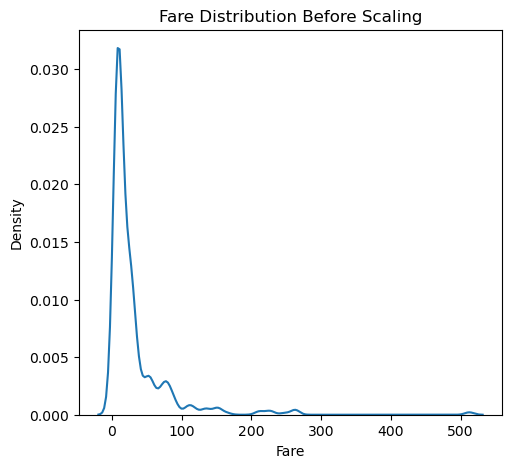

In [8]:
# --- TASK 4: SCALING ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(df['Fare'], bw_adjust=0.5)
plt.title('Fare Distribution Before Scaling')

In [9]:
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

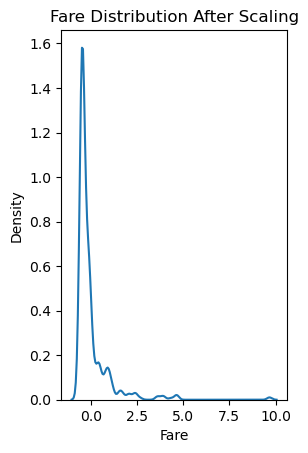

In [10]:
plt.subplot(1, 2, 2)
sns.kdeplot(df['Fare'], bw_adjust=0.5)
plt.title('Fare Distribution After Scaling')
plt.show()


In [11]:
# Final output 
print("Task 4 Complete! Data ka naya look:")
print(df.head())

Task 4 Complete! Data ka naya look:
   Survived  Pclass  Sex       Age      Fare  Embarked_Q  Embarked_S
0         0       3    1 -0.565736 -0.502445       False        True
1         1       1    0  0.663861  0.786845       False       False
2         1       3    0 -0.258337 -0.488854       False        True
3         1       1    0  0.433312  0.420730       False        True
4         0       3    1  0.433312 -0.486337       False        True


In [12]:
# --- STEP 4: SAVE PROCESSED DATA ---
df.to_csv('Titanic_Task4_Encoded_Scaled.csv', index=False)
print("Clean file 'Titanic_Task4_Encoded_Scaled.csv' has been saved!")

Clean file 'Titanic_Task4_Encoded_Scaled.csv' has been saved!
